In [1]:
# ============================================================================
# 1. ORTAM KURULUMU VE HAM VERİ SETİNİN HAZIRLANMASI
# ============================================================================
import json
import random
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print("⏳ Ham veriler py150 JSON dosyasından okunuyor...")
ast_verileri = []
with open("archive/py150/python100k_train.json", "r") as f:
    for i, satir in enumerate(f):
        if i >= 20000:  
            break
        ast_verileri.append(json.loads(satir))

df = pd.DataFrame({"ast_nodes": ast_verileri})
df["label"] = 0  # Hatasız kodlar

def ast_boz(ast_liste):
    bozuk_ast = json.loads(json.dumps(ast_liste))
    if len(bozuk_ast) > 2:
        secilen_index = random.randint(1, len(bozuk_ast) - 1)
        hata_turu = random.choice(["tip_degistir", "cocuk_sil", "deger_sil"])
        if hata_turu == "tip_degistir": bozuk_ast[secilen_index]["type"] = "HataliDugum"
        elif hata_turu == "cocuk_sil":
            if "children" in bozuk_ast[secilen_index]: del bozuk_ast[secilen_index]["children"]
            else: bozuk_ast[secilen_index]["type"] = "HataliDugum" 
        elif hata_turu == "deger_sil":
            if "value" in bozuk_ast[secilen_index]: del bozuk_ast[secilen_index]["value"]
            else: bozuk_ast[secilen_index]["type"] = "HataliDugum"
    return bozuk_ast

# Sentetik hataları üretip birleştirme
df_bozulacaklar = df.sample(frac=0.5, random_state=42).copy()
df_bozulacaklar["ast_nodes"] = df_bozulacaklar["ast_nodes"].apply(ast_boz)
df_bozulacaklar["label"] = 1  

final_df = pd.concat([df, df_bozulacaklar], ignore_index=True)
df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Ham Veri Yüklendi! Toplam Örnek Sayısı: {df.shape[0]}")

⏳ Ham veriler py150 JSON dosyasından okunuyor...
✅ Ham Veri Yüklendi! Toplam Örnek Sayısı: 30000


In [2]:
# ============================================================================
# 2. VERİ SIZINTISINI (DATA LEAKAGE) ÖNLEME - TRAIN / TEST SPLIT
# ============================================================================
from sklearn.model_selection import train_test_split

# JSON listesi halindeki AST düğümlerini yan yana kelimelere dönüştüren normalizasyon fonksiyonu
def ast_to_text(ast_liste):
    return " ".join([dugum.get("type", "") for dugum in ast_liste])

# Dönüşümü uygula
df['ast_text'] = df['ast_nodes'].apply(ast_to_text)

X = df['ast_text']
y = df['label']

# %80 Eğitim, %20 Test oranında stratify (dengeli) bölme
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"🎯 Veri Sızıntısına Karşı Güvenli Bölme Tamamlandı:")
print(f"   - Eğitim Kümesi (Train): {len(X_train_raw)} örnek")
print(f"   - Test Kümesi (Test):   {len(X_test_raw)} örnek")

🎯 Veri Sızıntısına Karşı Güvenli Bölme Tamamlandı:
   - Eğitim Kümesi (Train): 24000 örnek
   - Test Kümesi (Test):   6000 örnek


In [3]:
# ============================================================================
# 3. GELİŞMİŞ TF-IDF VEKTÖRLEŞTİRME VE NORMALİZASYON
# ============================================================================
from sklearn.feature_extraction.text import TfidfVectorizer

# min_df=2: En az iki farklı kod bloğunda geçmeyen çok nadir gürültü düğümleri siler.
# max_features=1000: En etkili 1000 özelliği seçerek boyutu normalize eder.
vectorizer = TfidfVectorizer(max_features=1000, min_df=2, lowercase=True)

# ÇOK ÖNEMLİ: fit_transform sadece TRAIN setine uygulanır. 
# TEST seti ise sadece transform edilir! (Sızıntıyı önleyen altın kural)
X_train_vectorized = vectorizer.fit_transform(X_train_raw)
X_test_vectorized = vectorizer.transform(X_test_raw)

# Oluşan matrislerin yoğunluğunu DataFrame'e çevirip jüri için görselleştirelim
özellik_isimleri = vectorizer.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_vectorized.toarray(), columns=özellik_isimleri)

print(f"🚀 Matematiksel Normalizasyon Tamamlandı!")
print(f"   - Eğitim Matrisi Boyutu: {X_train_vectorized.shape}")
print(f"   - Test Matrisi Boyutu:   {X_test_vectorized.shape}\n")
print("📊 İlk 5 Örneğe Ait Normalize Edilmiş TF-IDF Matris Kesiti (İlk 5 Özellik):")
print(X_train_df.iloc[:5, :5])

🚀 Matematiksel Normalizasyon Tamamlandı!
   - Eğitim Matrisi Boyutu: (24000, 136)
   - Test Matrisi Boyutu:   (6000, 136)

📊 İlk 5 Örneğe Ait Normalize Edilmiş TF-IDF Matris Kesiti (İlk 5 Özellik):
      alias      args  arguments  assert    assign
0  0.051468  0.000000   0.000000     0.0  0.000000
1  0.568489  0.000000   0.000000     0.0  0.000000
2  0.060889  0.069539   0.069548     0.0  0.097878
3  0.146844  0.083853   0.083863     0.0  0.150214
4  0.034072  0.103766   0.103779     0.0  0.069707


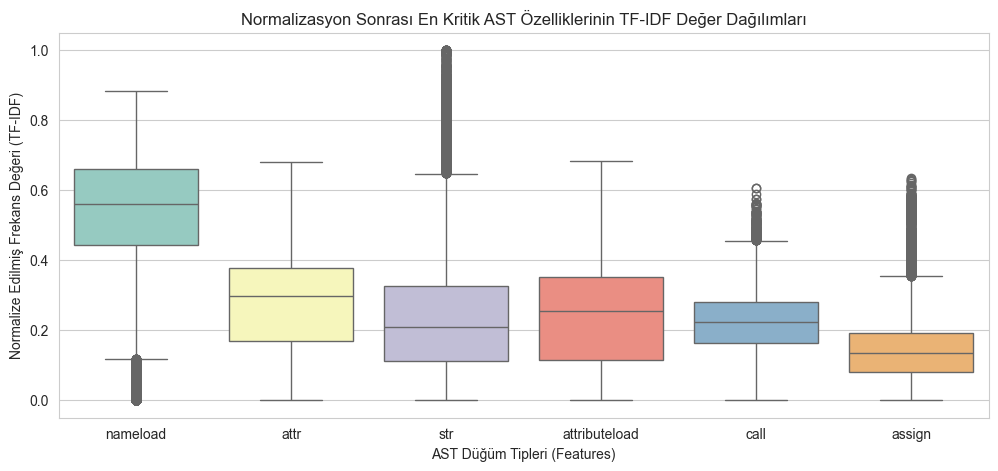

In [4]:
# ============================================================================
# 4. PREPROCESSING SONRASI ÖZELLİK DAĞILIM ANALİZİ (GÖRSELLEŞTİRME)
# ============================================================================
# En yüksek varyansa/değere sahip ilk 6 özelliği seçelim
popüler_özellikler = X_train_df.sum().sort_values(ascending=False).index[:6]

plt.figure(figsize=(12, 5))
sns.boxplot(data=X_train_df[popüler_özellikler], palette="Set3")
plt.title("Normalizasyon Sonrası En Kritik AST Özelliklerinin TF-IDF Değer Dağılımları")
plt.xlabel("AST Düğüm Tipleri (Features)")
plt.ylabel("Normalize Edilmiş Frekans Değeri (TF-IDF)")
plt.show()

In [5]:
# ============================================================================
# 5. İŞLENMİŞ VERİLERİN VE VEKTÖRLEŞTİRİCİNİN KAYDEDİLMESİ
# ============================================================================
import joblib
import os

# Kayıt klasörünü kontrol et veya oluştur
os.makedirs("processed_data", exist_ok=True)

# 1. Eğitime hazır normalize matrisleri kaydediyoruz
joblib.dump(X_train_vectorized, 'processed_data/X_train_normalized.pkl')
joblib.dump(X_test_vectorized, 'processed_data/X_test_normalized.pkl')
joblib.dump(y_train, 'processed_data/y_train.pkl')
joblib.dump(y_test, 'processed_data/y_test.pkl')

# 2. Chatbot arayüzünde canlı kodları çevirmek için kullanacağımız Vectorizer'ı kaydediyoruz
joblib.dump(vectorizer, 'processed_data/fitted_vectorizer.pkl')

print("💾 Tüm önişleme çıktıları 'processed_data/' klasörüne başarıyla kaydedildi!")
print("   - X_train_normalized.pkl (Eğitim Özellikleri)")
print("   - X_test_normalized.pkl (Test Özellikleri)")
print("   - fitted_vectorizer.pkl (Chatbot'un kullanacağı canlı çevirmen)")

💾 Tüm önişleme çıktıları 'processed_data/' klasörüne başarıyla kaydedildi!
   - X_train_normalized.pkl (Eğitim Özellikleri)
   - X_test_normalized.pkl (Test Özellikleri)
   - fitted_vectorizer.pkl (Chatbot'un kullanacağı canlı çevirmen)
